# Data-efficient Bayesian-guided design selection from large candidate sets: Application to hyperelastic stochastic metamaterials

This notebook reproduces every code-generated figure and table in the manuscript. It only loads cached results and plots them; no training or design search is performed here.

**Prerequisite.** Fetch the archived data, from the repository root:
```bash
python download_data.py
```

This provides the microstructures, the oracle responses, the selected surrogate checkpoint, and every cached result the notebook reads.

To regenerate those caches instead of downloading them, run the stages below in order. These are the computationally expensive steps, and none of them is needed to reproduce the figures:
```bash
python -m experiments.baygds.run_feature_engineering                 # PC score descriptors
python -m experiments.baygds.run_active_learning                     # train the GP surrogate
python -m experiments.baygds.run_inverse_design                      # full inverse design sweep
python -m experiments.sensitivity.run_pc_dimension                   # PC dimension sensitivity
python -m experiments.sensitivity.run_lambda_sensitivity             # uncertainty weight diagnostic
python -m experiments.baselines.run_baseline_comparison --n-jobs 4   # search baselines
```


In [1]:
%matplotlib inline
import importlib
import sys
import warnings
from pathlib import Path

def find_repo_root(start: Path | None = None):
    """Find the repository root regardless of where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir() and (candidate / "reproduction").is_dir():
            return candidate
    raise RuntimeError("Could not locate repository root. Launch Jupyter from the BayGDS repository or one of its subdirectories.")

ROOT = find_repo_root()
sys.path.insert(0, str(ROOT.resolve()))
sys.path.insert(0, str((ROOT / "src").resolve()))

import numpy as np
import torch
import torch.nn.functional as F

# Always reload the plotting module from this repository, not a stale kernel import.
sys.modules.pop("reproduction.plotting", None)
sys.modules.pop("reproduction", None)
plotting = importlib.import_module("reproduction.plotting")
if Path(plotting.__file__).resolve() != (ROOT / "reproduction/plotting.py").resolve():
    raise RuntimeError(f"Imported plotting module from unexpected path: {plotting.__file__}")
setup_latex_style = plotting.setup_latex_style
setup_latex_style()

warnings.filterwarnings("ignore", message=r"`torch\.jit\.script` is deprecated")

FIGURES = ROOT / "output/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Setup complete.


---
## 1. Sample Microstructures

Load the 50,000 stochastic metamaterial unit cells and visualise a random subset
(`sample_designs.pdf`).


Loaded 50000 structures of size 96x96


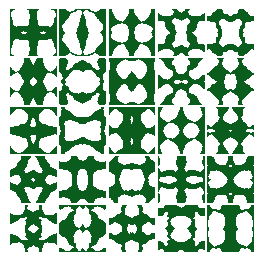

Saved: sample_designs.pdf


In [2]:
from reproduction.plotting import plot_sample_designs

structures_data = np.load(ROOT / "data/structures/structures.npz", allow_pickle=True)
structures = structures_data["structures"]
print(f"Loaded {structures.shape[0]} structures of size {structures.shape[1]}x{structures.shape[2]}")

STRUCTURE_SEED = 1235
plot_sample_designs(structures, FIGURES / "sample_designs.pdf", seed=STRUCTURE_SEED)
print("Saved: sample_designs.pdf")

---
## 2. Feature Engineering (PCA Descriptors)

The low-dimensional microstructure descriptors $\mathbf{z}_i \in \mathbb{R}^{n_z}$
are obtained by applying PCA to solid and interface two-point correlations.


In [3]:
PCA_PATH = ROOT / "data/pca/pc_scores.npz"
pca_data = np.load(PCA_PATH, allow_pickle=True)
pca_scores = pca_data["PCA_components"]
print(f"PC scores loaded: shape={pca_scores.shape}")

PC scores loaded: shape=(50000, 8)


---
## 2.1. PC Dimension Sensitivity

This fixed supervised study uses 4,000 training structures, 1,000 held-out
test structures, and 200 fixed inducing points to isolate the influence of
retaining one to eight PC scores. It does not use active learning.


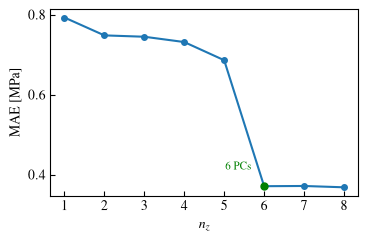

Saved: pc_dimension_curve.pdf


In [4]:
from reproduction.plotting import plot_pc_dimension_curve

PC_STUDY_DIR = ROOT / "output/studies/pc_dimension"
pc_metrics = np.load(PC_STUDY_DIR / "metrics.npz")
plot_pc_dimension_curve(
    pc_metrics["n_pcs"],
    pc_metrics["test_mae_mpa"],
    FIGURES / "pc_dimension_curve.pdf",
    selected_n_pcs=6,
)
print("Saved: pc_dimension_curve.pdf")

---
## 3. Deformation Sampling

Visualise the sampled deformation states in the invariant space
$(I_1-3,\;(I_4-1)^2,\;(I_6-1)^2)$
(`deformation_sampling.pdf`).


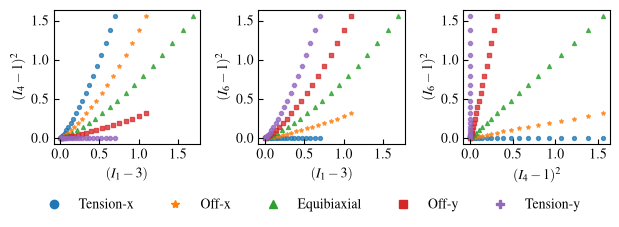

Saved: deformation_sampling.pdf


In [5]:
from data_utils import load_dataset, select_fit_indices_0deg
from reproduction.plotting import plot_deformation_sampling

oracle_0deg = load_dataset(ROOT / "data/oracle/oracle_0deg.npz")
tags_0 = oracle_0deg["deformation_tags"]
F_grid_0 = oracle_0deg["deformation_grid"]
fit_idx_0, _ = select_fit_indices_0deg(tags_0, F_grid_0)

plot_deformation_sampling(F_grid_0, tags_0, fit_idx_0,
                          FIGURES / "deformation_sampling.pdf", rotation=0)
print("Saved: deformation_sampling.pdf")

---
## 4. Active Learning Convergence

Plot the MAE convergence curve (`al_curve.pdf`) and apply the
stopping rule:
$$\Delta_t = \frac{1}{L}\sum_{\tau=t-L+1}^{t}
    \frac{|\mathrm{MAE}_\tau - \mathrm{MAE}_{\tau-1}|}{\mathrm{MAE}_{\tau-1}}
    \le \epsilon$$
with $L=5$ and $\epsilon=10^{-3}$.


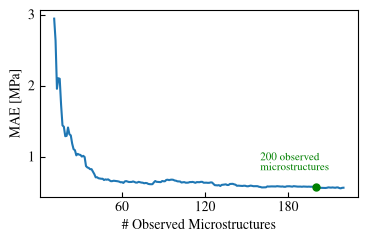

Saved: al_curve.pdf
Stopping criterion met at iteration 190 (200 observed microstructures)
Model checkpoint: output/surrogate/active_learning/al_model_selected.pt


In [6]:
import json
from reproduction.plotting import plot_al_curve, find_stopping_iteration

SURROGATE_DIR = ROOT / "output/surrogate/active_learning"
AL_CONFIG = SURROGATE_DIR / "al_config.json"


def _first_existing(*paths):
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError("None of these files exist: " + ", ".join(str(p) for p in paths))


with open(AL_CONFIG) as f:
    train_cfg = json.load(f)

if "T_max" in train_cfg:
    t_max = int(train_cfg["T_max"])
elif "iters" in train_cfg:
    t_max = int(train_cfg["iters"])
else:
    raise KeyError(f"Missing T_max/iters in {AL_CONFIG}")

state_path = SURROGATE_DIR / "al_state.npz"
splits_path = SURROGATE_DIR / "al_splits.npz"
if state_path.exists():
    state = np.load(state_path, allow_pickle=True)
    n_initial = int(np.array(state["initial_train_idx"]).size)
elif splits_path.exists():
    splits = np.load(splits_path, allow_pickle=True)
    n_initial = int(np.array(splits["initial_train_idx"]).size)
elif "n_init" in train_cfg:
    n_initial = int(train_cfg["n_init"])
else:
    raise KeyError(f"Missing n_init in {AL_CONFIG} and {splits_path} not found")

HISTORY_PATH = _first_existing(
    SURROGATE_DIR / "al_state.npz",
    SURROGATE_DIR / f"al_history_ntrain_{n_initial + t_max}.npz",
    SURROGATE_DIR / f"al_history_iter_{t_max:04d}.npz",
    SURROGATE_DIR / "al_history.npz",
)

hist = np.load(HISTORY_PATH, allow_pickle=True)
mae_hist = np.array(hist.get("eval_mae_hist", []), dtype=float)

L = 5
epsilon = 1.0e-3

stop_iter = plot_al_curve(
    mae_hist, n_initial, FIGURES / "al_curve.pdf",
    L=L, epsilon=epsilon, max_iters=t_max,
)
print("Saved: al_curve.pdf")

MODEL_PATH = _first_existing(
    SURROGATE_DIR / "al_model_selected.pt",
    SURROGATE_DIR / f"al_model_ntrain_{n_initial + t_max}.pt",
    SURROGATE_DIR / f"al_model_iter_{t_max}.pt",
)
if stop_iter is not None:
    print(f"Stopping criterion met at iteration {stop_iter} "
          f"({n_initial + stop_iter} observed microstructures)")
print(f"Model checkpoint: {MODEL_PATH.relative_to(ROOT)}")


---
## 5. Constitutive Parameter Distributions

Compute the posterior expected constitutive parameters
$\mathbb{E}[\theta_{I_1}]$, $\mathbb{E}[\theta_{I_4}]$, $\mathbb{E}[\theta_{I_6}]$
for all 50,000 microstructures via Monte Carlo sampling from the trained
LMC surrogate (`param_distribution.pdf`).


In [7]:
import json
from data_utils import load_pca
from gp_core import (
    build_svgp_from_config, normalize_z,
)

device = torch.device("cpu")
AL_CONFIG = SURROGATE_DIR / "al_config.json"

with open(AL_CONFIG) as f:
    train_cfg = json.load(f)

n_pca = train_cfg.get("n_pca_components", 6)
pcs = load_pca(ROOT / "data/pca/pc_scores.npz", n_pca)
z_raw = torch.from_numpy(pcs.astype(np.float32)).to(device)
z_mean = z_raw.mean(0, keepdim=True)
z_std = z_raw.std(0, keepdim=True).clamp_min(1e-8)
z_norm = normalize_z(z_raw, z_mean, z_std)

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state_dict = ckpt["model_state"]
inducing_shape = state_dict[
    "variational_strategy.base_variational_strategy.inducing_points"
].shape
coeff = state_dict["variational_strategy.lmc_coefficients"]
num_latents, num_tasks = coeff.shape
rank = int(num_latents - num_tasks)

model = build_svgp_from_config(
    torch.zeros(inducing_shape, device=device), num_tasks, rank, train_cfg,
).to(device)
model.load_state_dict(state_dict)
model.eval()
print(f"Model loaded: {num_tasks} tasks, rank={rank}")

Model loaded: 3 tasks, rank=3


Parameter distributions computed: shape=(50000, 3)


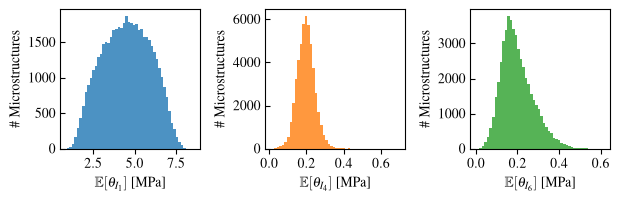

Saved: param_distribution.pdf


In [8]:
from reproduction.plotting import plot_param_distribution

MC_SAMPLES = 64
BATCH = 1024

# The posterior is summarised by Monte-Carlo sampling, so the generator is
# seeded to make this figure reproducible bit for bit. With 64 samples per
# structure the estimate is already visually converged; the seed only fixes
# the residual sampling noise.
MC_SEED = 0
torch.manual_seed(MC_SEED)
params_list = []
with torch.no_grad():
    for i in range(0, z_norm.shape[0], BATCH):
        zb = z_norm[i:i+BATCH]
        out = model(zb)
        samples = out.rsample(torch.Size([MC_SAMPLES]))
        params_list.append((F.softplus(samples) + 1e-6).mean(dim=0))
params_np = torch.cat(params_list, dim=0).cpu().numpy()
print(f"Parameter distributions computed: shape={params_np.shape}")

plot_param_distribution(params_np, FIGURES / "param_distribution.pdf")
print("Saved: param_distribution.pdf")

---
## 6. Inverse Design Results

Bayesian-guided inverse design: given $\mathbf{P}^{\star}$, find
$\mathbf{M}^{\star}$ minimising $\overline{\mathrm{nMAE}}$ below
threshold $\eta$, using at most $E_{\max}$ oracle evaluations.

The next subsection plots the target stress responses we aim to match; then
we summarise hit rates and related diagnostics.
`experiments/baygds/run_inverse_design.py` writes `output/inverse_design/sweep_settings.json` and embeds a fingerprint in each `inverse_design.npz`. A cache is reused only when settings match (seed, number of targets, $\eta$, $\omega_p$, $E_{\max}$, component combo, dataset / PCA / checkpoint paths, checkpoint mtime, MC batching, and training index set). The notebook checks `sweep_settings.json` against `SEED`, `N_TARGETS`, `eta`, `omega_p`, and the selected surrogate checkpoint.


In [9]:
import json

import inverse_design as inv
from reproduction.plotting import _combo_label, _combo_key, _hit_rate, _threshold_met

ctx = inv.setup(
    dataset_path=ROOT / "data/oracle/oracle_45deg.npz",
    pca_path=ROOT / "data/pca/pc_scores.npz",
    checkpoint_path=MODEL_PATH,
    train_config_path=AL_CONFIG,
)

omega_p = {"P11": 1.0, "P22": 1.0, "P12": 1.0}
eta = 5.0
E_max = 50
MARKER_EVALS = 20
SEED = 42
N_TARGETS = 1000

COMPONENT_COMBOS = [
    ("P11",), ("P22",), ("P12",),
    ("P11", "P22"), ("P11", "P12"), ("P22", "P12"),
    ("P11", "P22", "P12"),
]
EVAL_STEPS = [1] + list(range(10, 210, 10))

rng = np.random.default_rng(SEED)
candidates = np.setdiff1d(np.arange(ctx.targets_full.shape[0]), ctx.train_idx)
random_targets = rng.choice(candidates, size=N_TARGETS, replace=False)

RUN_DIR = ROOT / "output/inverse_design"


def _check_sweep_manifest() -> None:
    """Warn if notebook knobs disagree with ``experiments/baygds/run_inverse_design.py`` output."""
    mpath = RUN_DIR / "sweep_settings.json"
    if not mpath.is_file():
        print(
            "Note: sweep_settings.json missing — run python -m experiments.baygds.run_inverse_design "
            "or verify cached .npz files match SEED / N_TARGETS / eta / omega_p."
        )
        return
    m = json.loads(mpath.read_text(encoding="utf-8"))
    issues = []
    if int(m.get("target_sample_seed", -1)) != int(SEED):
        issues.append(
            f"target_sample_seed: manifest {m.get('target_sample_seed')} vs notebook {SEED}"
        )
    if int(m.get("n_targets", -1)) != int(N_TARGETS):
        issues.append(
            f"n_targets: manifest {m.get('n_targets')} vs notebook {N_TARGETS}"
        )
    if float(m.get("eta", -1.0)) != float(eta):
        issues.append(f"eta: manifest {m.get('eta')} vs notebook {eta}")
    mw = m.get("omega_p") or {}
    for k in ("P11", "P22", "P12"):
        if float(mw.get(k, -999.0)) != float(omega_p.get(k, 1.0)):
            issues.append(f"omega_p[{k}]: manifest {mw.get(k)} vs notebook {omega_p.get(k, 1.0)}")
    manifest_ckpt = m.get("checkpoint_path")
    if manifest_ckpt:
        # The manifest path is relative to the repository root. The sweep recorded
        # the checkpoint under its pre-release name, al_model_ntrain_<n>.pt; it is
        # archived as al_model_selected.pt. Both name the same selected model.
        n_train = json.loads(AL_CONFIG.read_text(encoding="utf-8"))["selected_n_train"]
        accepted = {Path(MODEL_PATH).name, f"al_model_ntrain_{n_train}.pt"}
        same_dir = (ROOT / manifest_ckpt).parent == Path(MODEL_PATH).parent
        if not (same_dir and Path(manifest_ckpt).name in accepted):
            issues.append(
                f"checkpoint_path: manifest {manifest_ckpt} vs notebook "
                f"{Path(MODEL_PATH).relative_to(ROOT)}"
            )
    if issues:
        print("WARNING: sweep_settings.json disagrees with notebook constants:")
        for line in issues:
            print(" ", line)
    else:
        print("sweep_settings.json matches notebook SEED / N_TARGETS / eta / omega_p / checkpoint.")


_check_sweep_manifest()

mpath = RUN_DIR / "sweep_settings.json"
if mpath.is_file():
    m = json.loads(mpath.read_text(encoding="utf-8"))
    from_file = np.asarray(m.get("random_target_indices", []), dtype=np.int64)
    if from_file.size and not np.array_equal(from_file, random_targets):
        print(
            "WARNING: random_targets from notebook RNG != sweep_settings.json list; "
            "plots use indices from loaded .npz (see target stress cell)."
        )


def load_run(combo_key, e_max):
    """Load a cached inverse design batch."""
    path = RUN_DIR / "runs" / _combo_key(combo_key) / f"eval_{e_max:04d}" / "inverse_design.npz"
    data = np.load(path, allow_pickle=True)
    return {k: data[k] for k in data.files}

# Load E_max=50 results for all combos
run_cache = {}
for combo in COMPONENT_COMBOS:
    combo_key = tuple(combo)
    run_cache[combo_key] = load_run(combo_key, E_max)
    print(f"{_combo_key(combo_key):<16s} R_eta = {_hit_rate(run_cache[combo_key]):.1f}%")

print("\nAll results loaded.")

[setup] structures=50000  rows=283  train=200  pca_dim=6  checkpoint=al_model_selected.pt
sweep_settings.json matches notebook SEED / N_TARGETS / eta / omega_p / checkpoint.
p11              R_eta = 100.0%
p22              R_eta = 100.0%
p12              R_eta = 99.7%
p11_p22          R_eta = 98.8%
p11_p12          R_eta = 98.3%
p22_p12          R_eta = 99.1%
p11_p22_p12      R_eta = 97.1%

All results loaded.


---
## 7. Target Stress Responses

Target stress $\mathbf{P}^{\star}$ vs deformation for the 1,000
selected microstructures (`target_stress.pdf`). This panel shows the
prescribed responses the inverse design aims to match.


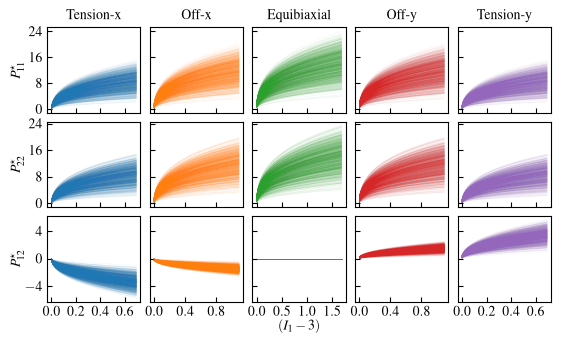

Saved: target_stress.pdf


In [10]:
from reproduction.plotting import plot_target_stress

combo_full = ("P11", "P22", "P12")
row_mask = np.array(inv._component_mask(ctx.row_labels_full, combo_full), dtype=np.int64)
targets_full_masked = ctx.targets_full[:, row_mask]

target_indices_plot = np.asarray(
    run_cache[combo_full]["random_target_indices"], dtype=np.int64
)

plot_target_stress(
    targets=targets_full_masked,
    tags_subset=ctx.tags_subset,
    F_grid_subset=ctx.F_grid_subset,
    target_indices=target_indices_plot,
    include_shear=ctx.include_shear,
    shear_rotations=ctx.shear_rotations,
    row_mask=row_mask,
    out_path=FIGURES / "target_stress.pdf",
)
print("Saved: target_stress.pdf")

---
## 8. Inverse Design Summary

Threshold hit rates $R_{\eta}^{(\le E_{\max})}$ and related columns for
all seven component combinations (`inverse_design_summary.csv`).


In [11]:
from reproduction.plotting import write_summary_table, _parity_indices, _parity_points, _r2

table_rows = []
for combo in COMPONENT_COMBOS:
    combo_key = tuple(combo)
    data = run_cache[combo_key]
    mask = np.array(inv._component_mask(ctx.row_labels_full, combo_key), dtype=np.int64)
    targets_masked = ctx.targets_full[:, mask]
    row_labels = [ctx.row_labels_full[i] for i in mask]

    target_indices = np.array(data.get("random_target_indices", []), dtype=np.int64)
    oracle_indices = _parity_indices(data, E_max)
    met = _threshold_met(data)
    counts = np.array(data.get("random_oracle_eval_counts", []), dtype=np.int64)

    rate_full = float(np.mean(met) * 100) if met.size else float("nan")
    rate_marker = float(np.mean((counts <= MARKER_EVALS) & met) * 100) if counts.size else float("nan")

    r2_map = {}
    for comp in ("P11", "P22", "P12"):
        x, y = _parity_points(targets_masked, row_labels, target_indices, oracle_indices, comp, "mean")
        r2_map[comp] = f"{_r2(x, y):.3f}" if x.size else "--"

    table_rows.append({
        "combo": _combo_key(combo_key),
        "hit_rate_pct": f"{rate_full:.1f}",
        "hit_rate_le_marker_pct": f"{rate_marker:.1f}",
        "r2_p11": r2_map["P11"],
        "r2_p22": r2_map["P22"],
        "r2_p12": r2_map["P12"],
    })

write_summary_table(table_rows, FIGURES)
print("Saved: inverse_design_summary.csv")

import pandas as pd
pd.DataFrame(table_rows)

Saved: inverse_design_summary.csv


,combo,hit_rate_pct,hit_rate_le_marker_pct,r2_p11,r2_p22,r2_p12
0,p11,100.0,99.9,0.992,--,--
1,p22,100.0,99.8,--,0.993,--
2,p12,99.7,98.7,--,--,0.987
3,p11_p22,98.8,97.8,0.989,0.990,--
4,p11_p12,98.3,95.8,0.989,--,0.982
5,p22_p12,99.1,96.5,--,0.987,0.977
6,p11_p22_p12,97.1,93.9,0.983,0.985,0.974


---
## 9. Budget-Constrained Threshold Hit Rates

$R_{\eta}^{(\le E_{\max})}$ vs oracle budget $E_{\max}$
(`hit_rate.pdf`).


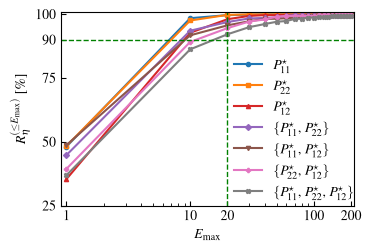

Saved: hit_rate.pdf


In [12]:
from reproduction.plotting import plot_hit_rate

hit_rate_curves = {}
for combo in COMPONENT_COMBOS:
    combo_key = tuple(combo)
    label = _combo_label(combo_key)
    hit_rate_curves[label] = []
    for max_ev in EVAL_STEPS:
        data = load_run(combo_key, max_ev)
        hit_rate_curves[label].append(_hit_rate(data))

plot_hit_rate(hit_rate_curves, FIGURES / "hit_rate.pdf", eval_steps=EVAL_STEPS)
print("Saved: hit_rate.pdf")

---
## 10. Oracle Evaluation Counts

Distribution of oracle evaluations $E_{\eta}$ for selected component
combinations (`oracle_counts.pdf`).


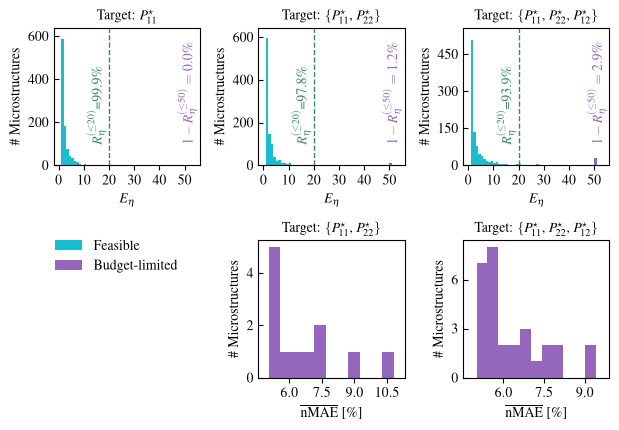

Saved: oracle_counts.pdf


In [13]:
from reproduction.plotting import plot_oracle_counts, HIST_COMBOS

hist_data = {}
hist_targets_map = {}
for combo in HIST_COMBOS:
    hist_data[tuple(combo)] = run_cache[tuple(combo)]
    mask = np.array(inv._component_mask(ctx.row_labels_full, combo), dtype=np.int64)
    hist_targets_map[tuple(combo)] = (
        ctx.targets_full[:, mask],
        [ctx.row_labels_full[i] for i in mask],
    )

plot_oracle_counts(hist_data, hist_targets_map, FIGURES / "oracle_counts.pdf")
print("Saved: oracle_counts.pdf")

---
## 10.1. Uncertainty Weight Sensitivity

The candidate score is evaluated as
$\phi_i = \mu_i + \gamma\dfrac{\overline{\mu}}{\overline{\sigma}}\sigma_i$. The published
automatic balance corresponds to $\gamma=1$. This diagnostic reuses the
same 1,000 targets and the full $(P_{11},P_{22},P_{12})$ objective. For each
target, a fixed pool of 50 candidates is preselected by surrogate mean
mismatch; the uncertainty-adjusted score changes only the order in which
these same candidates receive oracle evaluation. Because the pool holds exactly 50 candidates, all of them have been evaluated by $E_{\mathrm{hit}}=50$, so the improvement there is exactly zero for every multiplier. The hit rate improvement $\Delta R_{\eta}^{(\le E_{\mathrm{hit}})}=R_{\eta}^{(\le E_{\mathrm{hit}})}(\gamma)-R_{\eta}^{(\le E_{\mathrm{hit}})}(0)$ is reported against $\gamma$ at $E_{\mathrm{hit}}=1,10,20,$ and $50$, separating the low-budget effect from the converged result. The Monte Carlo mismatch terms are shared by every multiplier, and no GP retraining or active learning is performed.


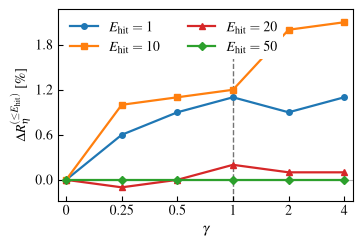

lambda/lambda_0  Delta E_hit=1  Delta E_hit=10  Delta E_hit=20  Delta E_hit=50 [%]
              0    0.0    0.0    0.0    0.0
           0.25    0.6    1.0   -0.1    0.0
            0.5    0.9    1.1    0.0    0.0
              1    1.1    1.2    0.2    0.0
              2    0.9    2.0    0.1    0.0
              4    1.1    2.1    0.1    0.0
Saved: lambda_sensitivity.pdf


In [14]:
from reproduction.plotting import plot_lambda_sensitivity

LAMBDA_STUDY_DIR = ROOT / "output/studies/lambda_sensitivity"
lambda_results = np.load(LAMBDA_STUDY_DIR / "results.npz")
plot_lambda_sensitivity(
    lambda_results["eval_steps"],
    lambda_results["gamma_values"],
    lambda_results["hit_rate_percent"],
    FIGURES / "lambda_sensitivity.pdf",
)
budget_columns = [0, 9, 19, 49]
selected_rates = lambda_results["hit_rate_percent"][:, budget_columns]
baseline = selected_rates[np.flatnonzero(
    np.isclose(lambda_results["gamma_values"], 0.0)
)[0]]
delta_rates = selected_rates - baseline
print("lambda/lambda_0  Delta E_hit=1  Delta E_hit=10  Delta E_hit=20  Delta E_hit=50 [%]")
for gamma, rates in zip(
    lambda_results["gamma_values"],
    delta_rates,
):
    print(f"{gamma:>15g}  " + "  ".join(f"{rate:5.1f}" for rate in rates))
print("Saved: lambda_sensitivity.pdf")

---
## 10.2. Full library Search Baselines and Descriptor Ablation

The proposed inverse design policy is compared with random search and
standard Bayesian optimization with expected improvement (BO--EI). A
descriptor ablation additionally repeats BO--EI using six PCs obtained
directly from flattened $96\times96$ binary structure images instead of
the six PCs of the solid/interface two-point-correlation descriptors.


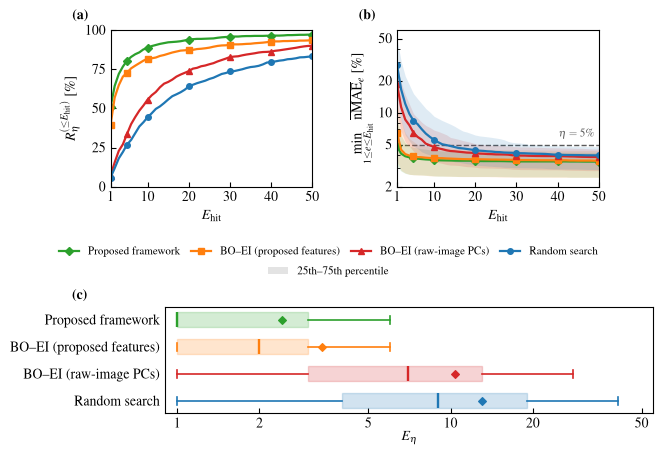

Hit rate
Method     E_hit=1   E_hit=10   E_hit=20   E_hit=50 [%]
Proposed framework                50.7   88.5   93.9   97.1
BO--EI (proposed features)        39.3   81.8   87.4   93.6
BO--EI (raw-image PCs)             7.1   55.6   73.8   90.0
Random search                      5.8   44.4   64.0   83.2

Median best-so-far aggregated nMAE
Method     E_hit=1   E_hit=10   E_hit=20   E_hit=50 [%]
Proposed framework                4.82   3.59   3.49   3.45
BO--EI (proposed features)        6.46   3.72   3.63   3.52
BO--EI (raw-image PCs)           18.57   4.74   4.16   3.81
Random search                    28.09   5.55   4.41   3.95
Saved: inverse_baseline_comparison.pdf


In [15]:
from reproduction.plotting import plot_inverse_baseline_comparison

from experiments.baselines.bo_ei_proposed_features import load_split_results

# The proposed, random search, and BO--EI engineered-feature results each live
# in their own directory; load_split_results restacks them per method.
BASELINE_ROOT = ROOT / "output/studies/baseline_comparison"
RAW_PCA_BO_DIR = BASELINE_ROOT / "bo_ei_raw_image_pcs"
baseline_results = load_split_results(BASELINE_ROOT)
if baseline_results is None:
    raise FileNotFoundError(f"Missing per-method baseline results under {BASELINE_ROOT}")
raw_pca_bo_results = np.load(RAW_PCA_BO_DIR / "results.npz")
method_labels = [str(label) for label in baseline_results["method_labels"]]
hit_rates = baseline_results["hit_rate_percent"]
ordered_eval_counts = np.stack([
    baseline_results["eval_counts"][method_labels.index("Proposed")],
    baseline_results["eval_counts"][method_labels.index("BO--EI")],
    baseline_results["eval_counts"][method_labels.index("Random")],
])
ordered_percentiles = np.stack([
    baseline_results["best_nmae_percentiles"][method_labels.index("Proposed")],
    baseline_results["best_nmae_percentiles"][method_labels.index("BO--EI")],
    baseline_results["best_nmae_percentiles"][method_labels.index("Random")],
])
plot_inverse_baseline_comparison(
    baseline_results["eval_steps"],
    hit_rates[method_labels.index("Proposed")],
    hit_rates[method_labels.index("BO--EI")],
    hit_rates[method_labels.index("Random")],
    FIGURES / "inverse_baseline_comparison.pdf",
    best_nmae_percentiles=ordered_percentiles,
    percentile_levels=baseline_results["best_nmae_percentile_levels"],
    raw_pca_bo_hit_rate=raw_pca_bo_results["hit_rate_percent"],
    raw_pca_bo_best_nmae_percentiles=raw_pca_bo_results["best_nmae_percentiles"],
    eval_counts_by_method=ordered_eval_counts,
    raw_pca_bo_eval_counts=raw_pca_bo_results["eval_counts"],
)
budget_columns = [0, 9, 19, 49]
display_labels = ["Proposed framework", "BO--EI (proposed features)", "BO--EI (raw-image PCs)", "Random search"]
display_hit_rates = [
    hit_rates[method_labels.index("Proposed")],
    hit_rates[method_labels.index("BO--EI")],
    raw_pca_bo_results["hit_rate_percent"],
    hit_rates[method_labels.index("Random")],
]
print("Hit rate")
print("Method     E_hit=1   E_hit=10   E_hit=20   E_hit=50 [%]")
for label, rates in zip(display_labels, display_hit_rates):
    selected = rates[budget_columns]
    print(f"{label:<31}  " + "  ".join(f"{rate:5.1f}" for rate in selected))
percentile_levels = baseline_results["best_nmae_percentile_levels"]
median_row = np.flatnonzero(np.isclose(percentile_levels, 50.0))[0]
median_best_nmae = baseline_results["best_nmae_percentiles"][:, median_row]
display_median_best_nmae = [
    median_best_nmae[method_labels.index("Proposed")],
    median_best_nmae[method_labels.index("BO--EI")],
    raw_pca_bo_results["best_nmae_percentiles"][median_row],
    median_best_nmae[method_labels.index("Random")],
]
print("\nMedian best-so-far aggregated nMAE")
print("Method     E_hit=1   E_hit=10   E_hit=20   E_hit=50 [%]")
for label, errors in zip(display_labels, display_median_best_nmae):
    selected = errors[budget_columns]
    print(f"{label:<31}  " + "  ".join(f"{error:5.2f}" for error in selected))
print("Saved: inverse_baseline_comparison.pdf")

---
## 11. Target vs Designed Stress

Parity plots comparing target $\mathbf{P}^{\star}$ and designed stress,
distinguishing feasible inverse solutions from budget-limited optima
(`parity.pdf`).


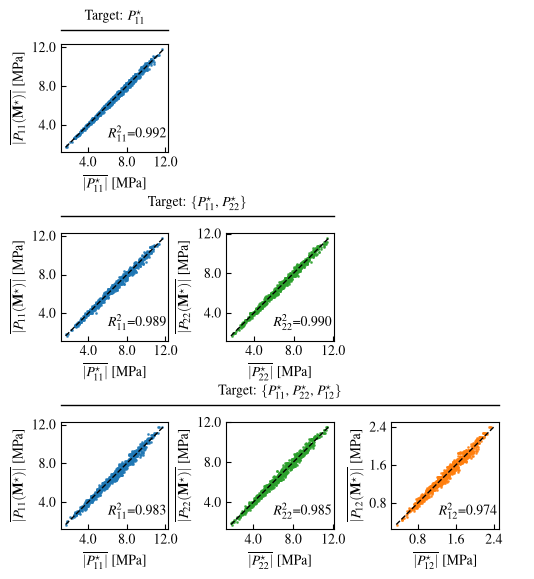

Saved: parity.pdf


In [16]:
from reproduction.plotting import plot_parity

PARITY_COMBOS = [("P11",), ("P11", "P22"), ("P11", "P22", "P12")]

parity_data = {}
parity_targets_map = {}
for combo in PARITY_COMBOS:
    parity_data[tuple(combo)] = run_cache[tuple(combo)]
    mask = np.array(inv._component_mask(ctx.row_labels_full, combo), dtype=np.int64)
    parity_targets_map[tuple(combo)] = (
        ctx.targets_full[:, mask],
        [ctx.row_labels_full[i] for i in mask],
    )

plot_parity(parity_data, parity_targets_map, FIGURES / "parity.pdf", budget=E_max)
print("Saved: parity.pdf")